# 01_eda — Prior + Observation exploratory data analysis

**Date:** 2026-05-14 (Thursday)

Understand the **Prior** (LOVECLIM dense glacial-period simulation) and the **Observation** (Liu 26 pollen-based reconstructions) datasets before building the autoencoder.

**Tier 1 sections (this notebook):**
1. Land/sea/ice mask of Prior - % valid cells and constancy across ages.
2. Distribution of `mtco`, `mtwa` - histograms, climatology maps, std maps.
3. Observation sparsity over time - sites per age.
4. Spatial bias of observations - map of all unique sites.
5. D–O event temporal coverage - Prior + Obs ages on a timeline.

**Tier 2 sections (added in a later pass once `paleoreco/splits.py` exists):**

6. Prior–obs residuals at co-located points.
7. Lag-1 temporal autocorrelation of Prior.
8. mtco↔mtwa per-cell correlation map.

In [ ]:
%load_ext autoreload
%autoreload 2

import os
import sys
sys.path.insert(0, os.path.abspath(".."))  # allow `from paleoreco...` when run from notebooks/

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from paleoreco.data import (
    build_prior_cube,
    verify_mask_constant_across_ages,
    GRID_SHAPE,
    VARS,
)

plt.rcParams["figure.dpi"] = 110

In [2]:
prior = build_prior_cube(
    prior_csv="../data/Prior.csv",
    cache_path="../data/cache/prior_cube.npz",
)
cube = prior["cube"]
ages = prior["ages"]
lats = prior["lats"]
lons = prior["lons"]
valid = prior["valid"]

print(f"cube shape : {cube.shape}, dtype {cube.dtype}")
print(f"N ages     : {len(ages)}  (range {ages.min()}..{ages.max()} yr BP)")
print(f"grid       : {len(lats)} lat x {len(lons)} lon")
print(f"lat range  : {lats.min()} .. {lats.max()}")
print(f"lon range  : {lons.min()} .. {lons.max()}")

cube shape : (804, 2, 32, 64), dtype float32
N ages     : 804  (range 29100..49175 yr BP)
grid       : 32 lat x 64 lon
lat range  : -84.375 .. 90.0
lon range  : -174.375 .. 180.0


## 1. Land/sea/ice mask of Prior

The Prior is LOVECLIM - a coupled atmosphere-ocean model whose `mtco` / `mtwa` are 2-metre air temperatures defined on **every** grid cell, ocean included. So we expect the geographic valid-mask to be uniformly `True`.

We also test whether the set of valid cells changes across the 804 ages. v1 of the autoencoder assumes a constant mask, so confirming this is on the EDA critical path.

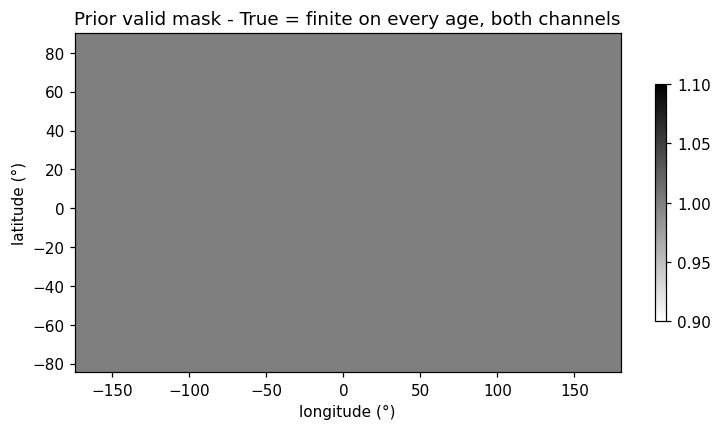

% valid cells : 100.00%   (2048 / 2048)
Mask constant across ages? True


In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(
    valid,
    origin="lower",
    extent=[lons.min(), lons.max(), lats.min(), lats.max()],
    cmap="gray_r",
    aspect="auto",
)
ax.set_xlabel("longitude (°)")
ax.set_ylabel("latitude (°)")
ax.set_title("Prior valid mask - True = finite on every age, both channels")
plt.colorbar(im, ax=ax, shrink=0.7)
plt.show()

print(f"% valid cells : {valid.mean() * 100:.2f}%   ({valid.sum()} / {valid.size})")
print(f"Mask constant across ages? {verify_mask_constant_across_ages(cube)}")

## 2. Distribution of `mtco`, `mtwa`

Three things per channel:

- **Histogram** over all (age, valid-cell) pairs - raw distribution of values the AE will be asked to reconstruct.
- **Climatology map**: per-cell mean across all 804 ages. Shows where it is reliably cold / warm.
- **Per-cell std map**: how much temperature varies over the 49–29 ka window at each cell. High std = the cell does interesting things during D–O events; low std = cell that barely changes (e.g. permanent ice, the case our `safe_valid` mask is designed to catch).

These statistics use **all** ages and are exploratory only - the train-only statistics that feed the AE come from `paleoreco.data.compute_zscore_stats` and are computed later, once the splits are defined.

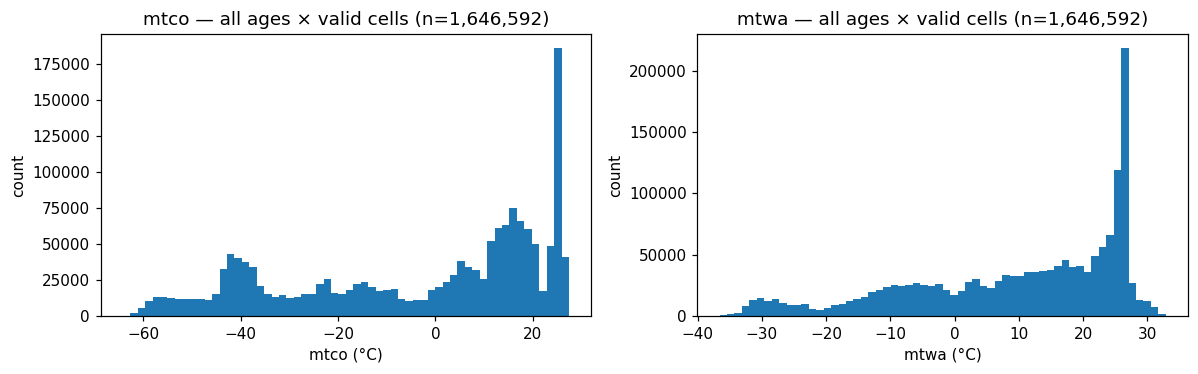

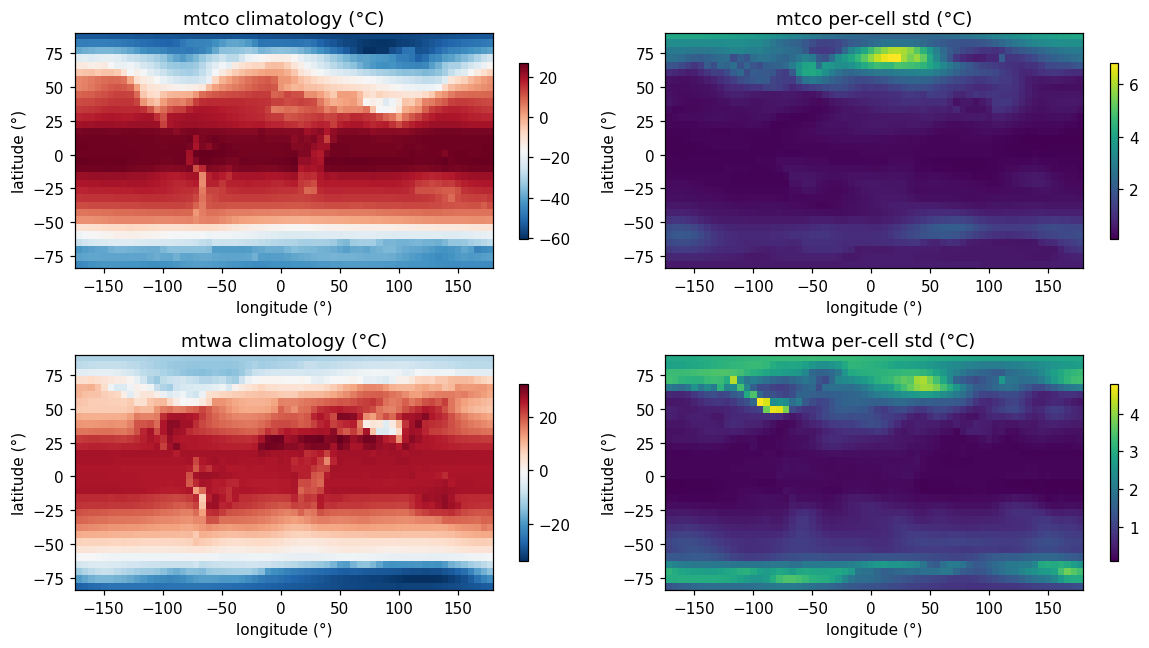

mtco: per-cell mean range  -60.3 ..  26.9 °C, median per-cell std 0.58 °C
mtwa: per-cell mean range  -33.9 ..  32.2 °C, median per-cell std 0.73 °C


In [ ]:
mean_all = cube.mean(axis=0)  # (2, n_lat, n_lon)
std_all  = cube.std(axis=0)

# Histograms over all (age, cell) pairs, restricted to valid cells.
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for c, name in enumerate(VARS):
    flat = cube[:, c][:, valid].ravel()
    axes[c].hist(flat, bins=60)
    axes[c].set_xlabel(f"{name} (°C)")
    axes[c].set_ylabel("count")
    axes[c].set_title(f"{name} — all ages × valid cells (n={flat.size:,})")
plt.tight_layout()
plt.show()

# Climatology + std maps. NaN out invalid cells for visual clarity.
fig, axes = plt.subplots(2, 2, figsize=(11, 6))
for c, name in enumerate(VARS):
    m = np.where(valid, mean_all[c], np.nan)
    s = np.where(valid, std_all[c],  np.nan)
    extent = [lons.min(), lons.max(), lats.min(), lats.max()]

    # Left maps (Climatology)
    im0 = axes[c, 0].imshow(m, origin="lower", extent=extent, cmap="RdBu_r", aspect="auto")
    axes[c, 0].set_title(f"{name} climatology (°C)")
    axes[c, 0].set_xlabel("longitude (°)")
    axes[c, 0].set_ylabel("latitude (°)")
    plt.colorbar(im0, ax=axes[c, 0], shrink=0.75)

    # Right maps (Standard Deviation)
    im1 = axes[c, 1].imshow(s, origin="lower", extent=extent, cmap="viridis", aspect="auto")
    axes[c, 1].set_title(f"{name} per-cell std (°C)")
    axes[c, 1].set_xlabel("longitude (°)")
    axes[c, 1].set_ylabel("latitude (°)")
    plt.colorbar(im1, ax=axes[c, 1], shrink=0.75)
    
plt.tight_layout()
plt.show()

for c, name in enumerate(VARS):
    cell_min = mean_all[c][valid].min()
    cell_max = mean_all[c][valid].max()
    cell_std = float(np.median(std_all[c][valid]))
    print(f"{name}: per-cell mean range {cell_min:6.1f} .. {cell_max:5.1f} °C, median per-cell std {cell_std:.2f} °C")

## 3. Observation sparsity over time

How many proxy sites are reported per age in `Observation.csv`? The autoencoder does not see the observations during training, but the *eventual* generative model will be conditioned on them, so we need to know how sparse the conditioning signal is at any given time step.

Total observation rows : 63,823
Unique observation ages: 768
Sites per age — min 4, median 87, mean 83.1, max 118


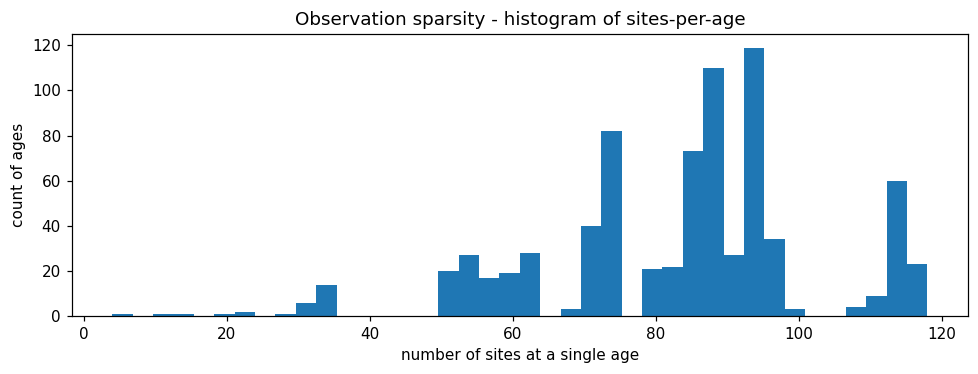

In [15]:
obs = pd.read_csv(
    "../data/Observation.csv",
    usecols=["age", "latitude", "longitude", "mtco", "mtwa", "sse_mtco", "sse_mtwa"],
)
n_per_age = obs.groupby("age").size()

print(f"Total observation rows : {len(obs):,}")
print(f"Unique observation ages: {n_per_age.size}")
print(
    f"Sites per age — min {n_per_age.min()}, "
    f"median {n_per_age.median():.0f}, "
    f"mean {n_per_age.mean():.1f}, "
    f"max {n_per_age.max()}"
)

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.hist(n_per_age.values, bins=40)
ax.set_xlabel("number of sites at a single age")
ax.set_ylabel("count of ages")
ax.set_title("Observation sparsity - histogram of sites-per-age")
plt.tight_layout()
plt.show()

## 4. Spatial bias of observations

Pollen-based proxies cluster heavily in the Northern Hemisphere / Eurasia (cf. Liu 26 Fig. 1b). Visualising every unique site location gives a quick sense of where the eventual conditional model will be receiving information and where it will have to extrapolate.

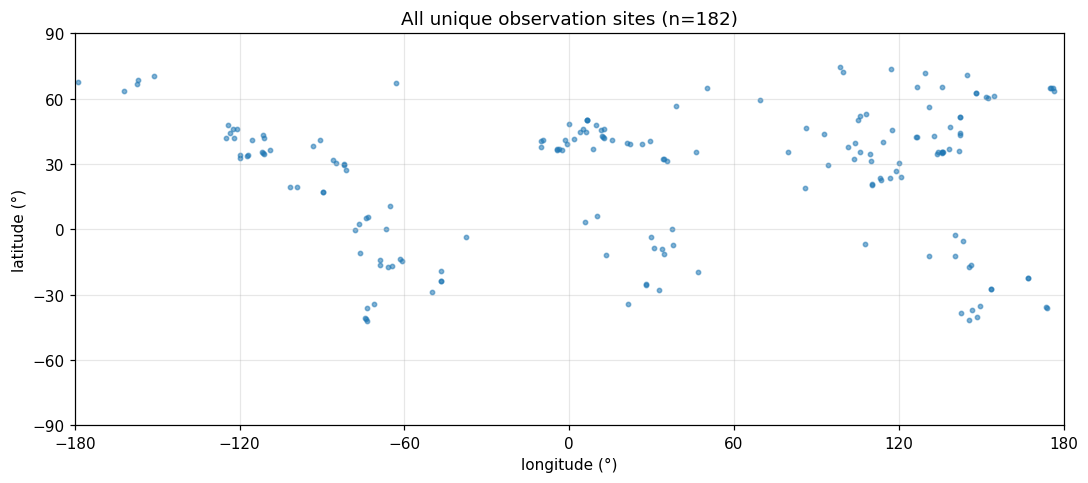

NH sites: 135  (74.2%)
SH sites: 47  (25.8%)


In [22]:
unique_sites = obs[["latitude", "longitude"]].drop_duplicates()

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.scatter(unique_sites["longitude"], unique_sites["latitude"], s=8, alpha=0.55)
ax.set_xlim(-180, 180)
ax.set_ylim(-90, 90)
ax.set_xticks(np.arange(-180, 181, 60))
ax.set_yticks(np.arange(-90, 91, 30))
ax.set_xlabel("longitude (°)")
ax.set_ylabel("latitude (°)")
ax.set_title(f"All unique observation sites (n={len(unique_sites)})")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

nh = int((unique_sites["latitude"] >  0).sum())
sh = int((unique_sites["latitude"] <= 0).sum())
print(f"NH sites: {nh}  ({nh / len(unique_sites) * 100:.1f}%)")
print(f"SH sites: {sh}  ({sh / len(unique_sites) * 100:.1f}%)")

## 5. D–O event temporal coverage

Plot every Prior age and every Observation age on a single timeline. Two things to look for: (i) do the Obs ages fall within the Prior age window? (ii) are there gaps where Obs ages are missing relative to Prior ages?

D–O event spans (DO-5 through DO-12) will be added as shaded bands once `paleoreco/splits.py` is built — boundary ages will be extracted from Liu 26 then.

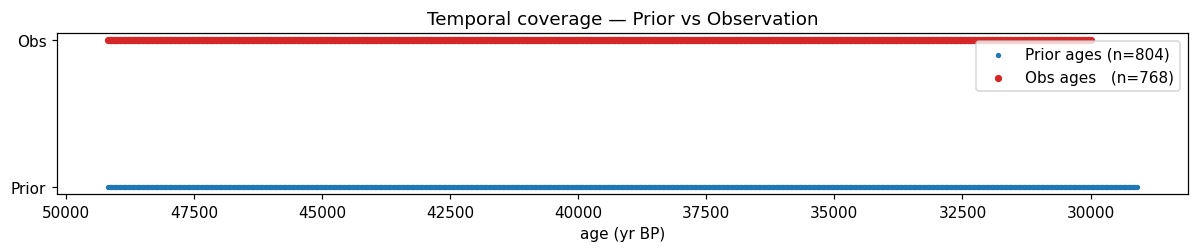

Obs ages inside Prior window : 768 / 768
Prior step (median delta age): 25 yr
Obs   step (median delta age): 25 yr


In [23]:
obs_ages = np.sort(obs["age"].unique())

fig, ax = plt.subplots(figsize=(11, 2.4))
ax.scatter(ages,     np.zeros_like(ages),     s=6,  label=f"Prior ages (n={len(ages)})",     color="C0")
ax.scatter(obs_ages, np.ones_like(obs_ages),  s=14, label=f"Obs ages   (n={len(obs_ages)})", color="C3")
ax.set_yticks([0, 1])
ax.set_yticklabels(["Prior", "Obs"])
ax.set_xlabel("age (yr BP)")
ax.set_title("Temporal coverage — Prior vs Observation")
ax.invert_xaxis()  # convention: younger ages on the right
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

in_prior_window = int(((obs_ages >= ages.min()) & (obs_ages <= ages.max())).sum())
print(f"Obs ages inside Prior window : {in_prior_window} / {len(obs_ages)}")
print(f"Prior step (median delta age): {int(np.median(np.diff(ages)))} yr")
print(f"Obs   step (median delta age): {int(np.median(np.diff(obs_ages)))} yr")

## Tier 1 - complete

Next: Tier 2 sections (6–8) added once `paleoreco/splits.py` exists. Tier 2 requires a defined train/val/test partition for the autocorrelation and residual analyses.